# Phase 2 - Braking: can the air system tell the story?

Building on the Phase 1 **braking** state, this notebook addresses three questions:
1. Can the **air-system sensors alone** tell when the train is braking - without using
   speed at all?
2. Are there distinct **braking-intensity classes** (gentle / hard / emergency), or is
   intensity a smooth continuum?
3. Does braking behaviour **change before a brake failure**?

The golden rule throughout (see **leakage** in the [Glossary](../README.md#glossary)):
the sensors that *defined* the braking state (motion) are never used to *predict* it.
The air-system sensors, which never touched the definition, are the predictors.

In [8]:
import pandas as pd
from pathlib import Path
from IPython.display import Image, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TABLES = ROOT / "results" / "tables"
P1 = ROOT / "results" / "plots" / "phase1"
P2 = ROOT / "results" / "plots" / "phase2"
LOGS = ROOT / "logs"
pd.set_option("display.max_columns", 40)
print("Project root:", ROOT)

Project root: c:\Users\MSC\Programming\Interdisciplinary Project


## 0. Keeping predictors and targets separate

**What was done:** every sensor was sorted into a role - *velocity* (motion; targets only),
*actuation* (the brake command), *auxiliary* (independent health sensors like reservoir
and load pressure) - and it was confirmed that the predictor sensors never overlap with what defined the
target.

In [9]:
import re

ledger = pd.read_csv(TABLES / "feature_roles.csv")
win = ledger[ledger.level == "window"].copy()
# Strip aggregation suffix to recover base sensor names
win["sensor"] = win["feature"].str.replace(r"__(mean|std|min|max|maj|mode)$", "", regex=True)

ROLE_LABELS = {
    "velocity":  "VELOCITY  - defines the target; never used as predictor",
    "actuation": "ACTUATION - brake-command sensors (direct brake engagement)",
    "auxiliary": "AUXILIARY - independent health/load sensors (main predictor pool, Tier A)",
}

for role, label in ROLE_LABELS.items():
    sensors = sorted(win[win.role == role]["sensor"].unique())
    print(f"\n{'─'*70}")
    print(f"{label}  [{len(sensors)} sensors]")
    print(f"{'─'*70}")
    for s in sensors:
        print(f"  {s}")


──────────────────────────────────────────────────────────────────────
VELOCITY  - defines the target; never used as predictor  [4 sensors]
──────────────────────────────────────────────────────────────────────
  TRAIN_SPEED_ACTUAL
  acceleration
  jerk
  velocity_change_rate

──────────────────────────────────────────────────────────────────────
ACTUATION - brake-command sensors (direct brake engagement)  [68 sensors]
──────────────────────────────────────────────────────────────────────
  CW1_BRAKE_CYLINDER_PRESSURE_BOGIE1
  CW1_BRAKE_CYLINDER_PRESSURE_BOGIE2
  CW1_PNEUMATIC_BRAKE_ACTIVE
  CW1_PNEUMATIC_BRAKING_FORCE_BOGIE1
  CW1_PNEUMATIC_BRAKING_FORCE_BOGIE2
  CW1_PROPORTIONAL_VALVE_PRESSURE_AVAILABLE_BOGIE1
  CW1_PROPORTIONAL_VALVE_PRESSURE_AVAILABLE_BOGIE2
  CW1_PROPORTIONAL_VALVE_PRESSURE_BOGIE1
  CW1_PROPORTIONAL_VALVE_PRESSURE_BOGIE2
  CW1_SPRING_BRAKE_ACTIVE_BOGIE1
  CW1_SPRING_BRAKE_ACTIVE_BOGIE2
  CW1_SPRING_BRAKE_PRESSURE_BOGIE1
  CW1_SPRING_BRAKE_PRESSURE_BOGIE2
  CW2_BR

## 1. Braking events (and a reality check)

**What was done:** a braking event = one continuous stretch of the braking state. Events were also
flagged for whether the train was genuinely decelerating.

In [10]:
display(pd.read_csv(TABLES / "event_summary.csv"))

,metric,value
0,n_events,126702.000000
1,n_real_deceleration,126635.000000
2,frac_real_deceleration,0.999500
3,duration_mean_s,23.444018
4,duration_median_s,20.000000
5,duration_p95_s,30.000000
6,events_7d_pre_failure,23033.000000
7,events_30d_pre_failure,82664.000000
8,v1_event_count,157823.000000
9,ratio_vs_v1,0.803000


**What it means:** ~127,000 braking events, and **99.9% are genuine decelerations** - the old "parked with brake held" contamination is gone.

## 2. Can the air sensors alone detect braking?

**What was done:** "braking vs not" was predicted for each window using only air-system sensors
(no speed). Two tiers - *auxiliary only*, then *+ the brake command* - and three
transparent models (decision tree, LDA, RF) were scored on unseen data.

,tier,model,n_features,accuracy,balanced_accuracy,precision_braking,recall_braking,f1_braking,roc_auc
0,auxonly,dt,60,0.731,0.796,0.424,0.906,0.577,0.878
1,auxonly,lda,60,0.820,0.621,0.621,0.287,0.392,0.813
2,auxonly,qda,60,0.521,0.693,0.295,0.983,0.454,0.844
3,auxonly,rf,60,0.766,0.831,0.462,0.941,0.620,0.921
4,auxonly,lr,60,0.719,0.728,0.397,0.744,0.517,0.814
5,auxonly,pca_lda,60,0.814,0.596,0.609,0.230,0.334,0.792
6,full,dt,180,0.754,0.825,0.449,0.945,0.609,0.910
7,full,lda,180,0.877,0.726,0.858,0.473,0.610,0.924
8,full,qda,180,0.844,0.746,0.622,0.583,0.602,0.901
9,full,rf,180,0.818,0.869,0.528,0.956,0.680,0.954


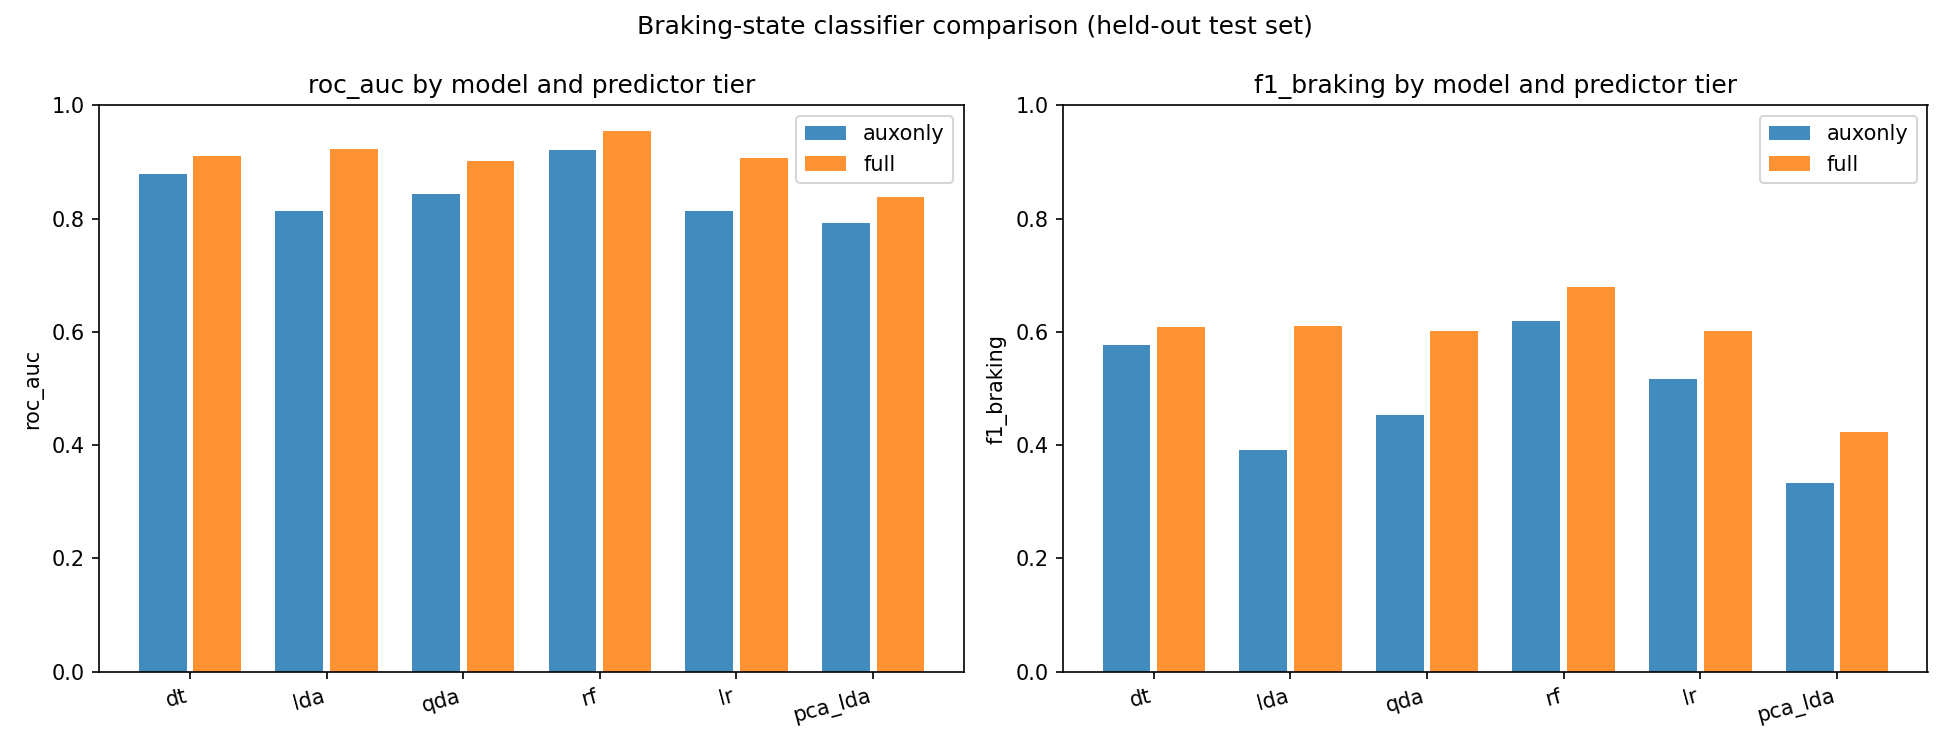

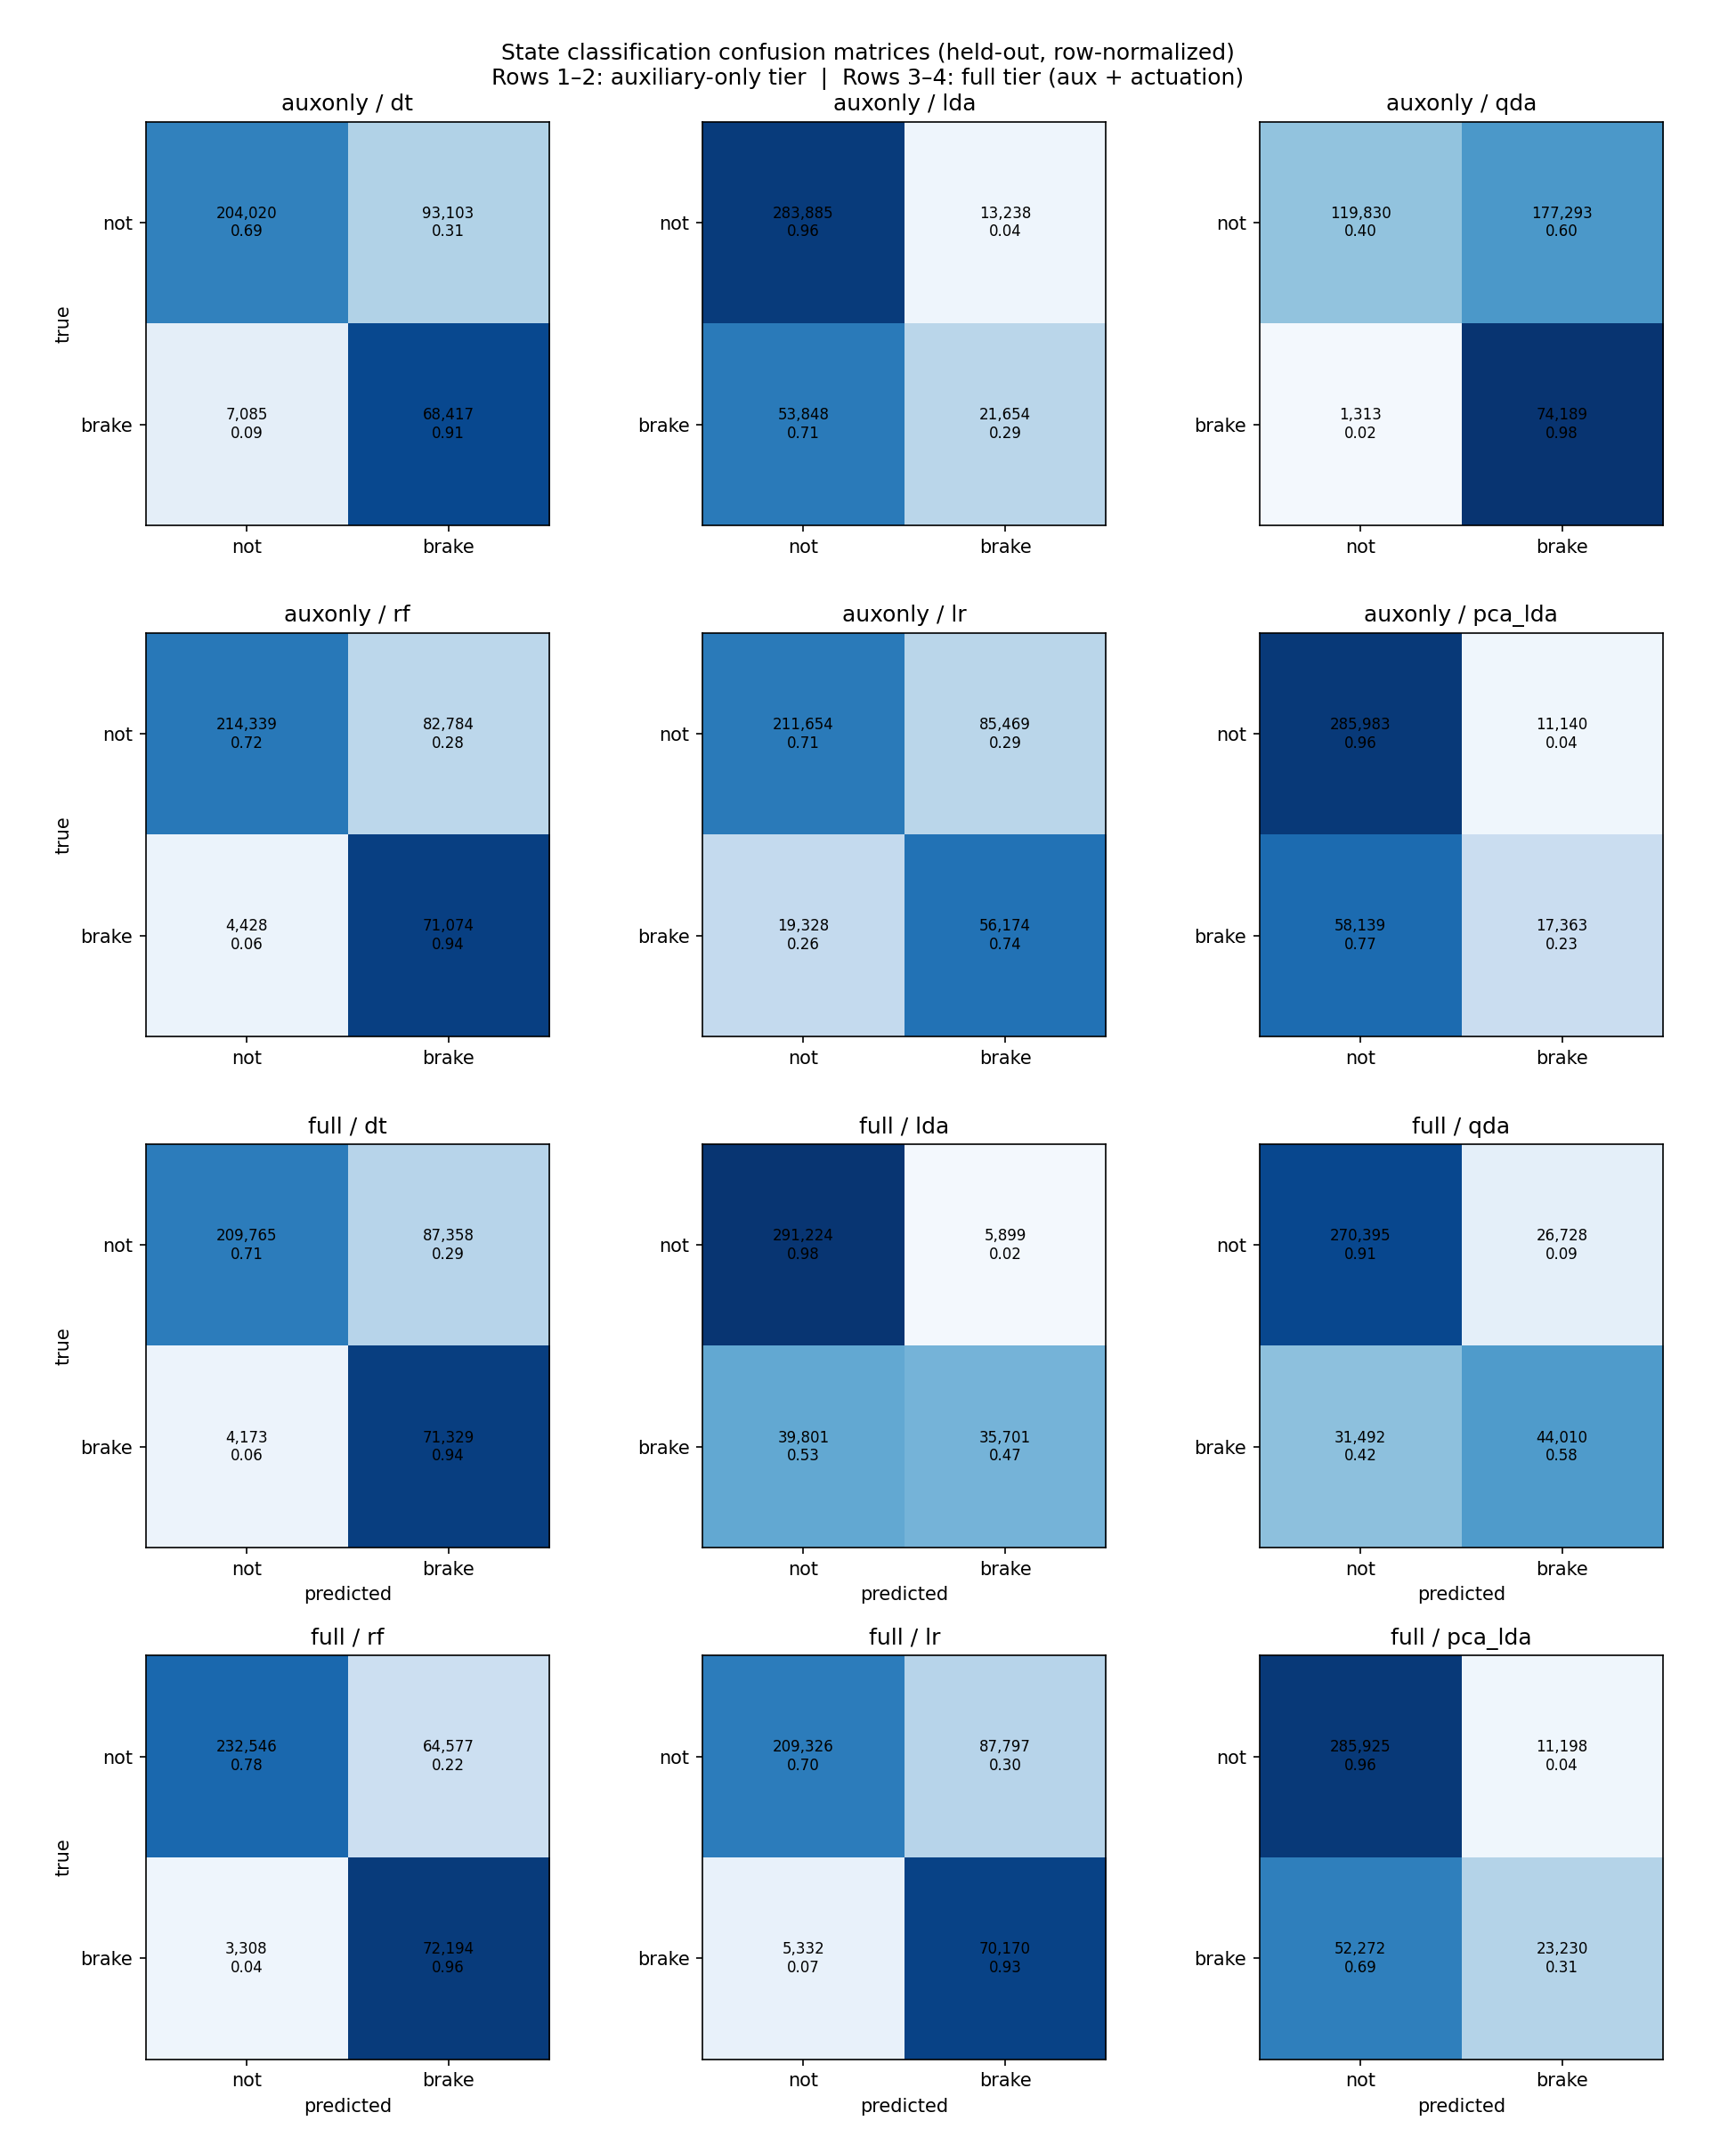

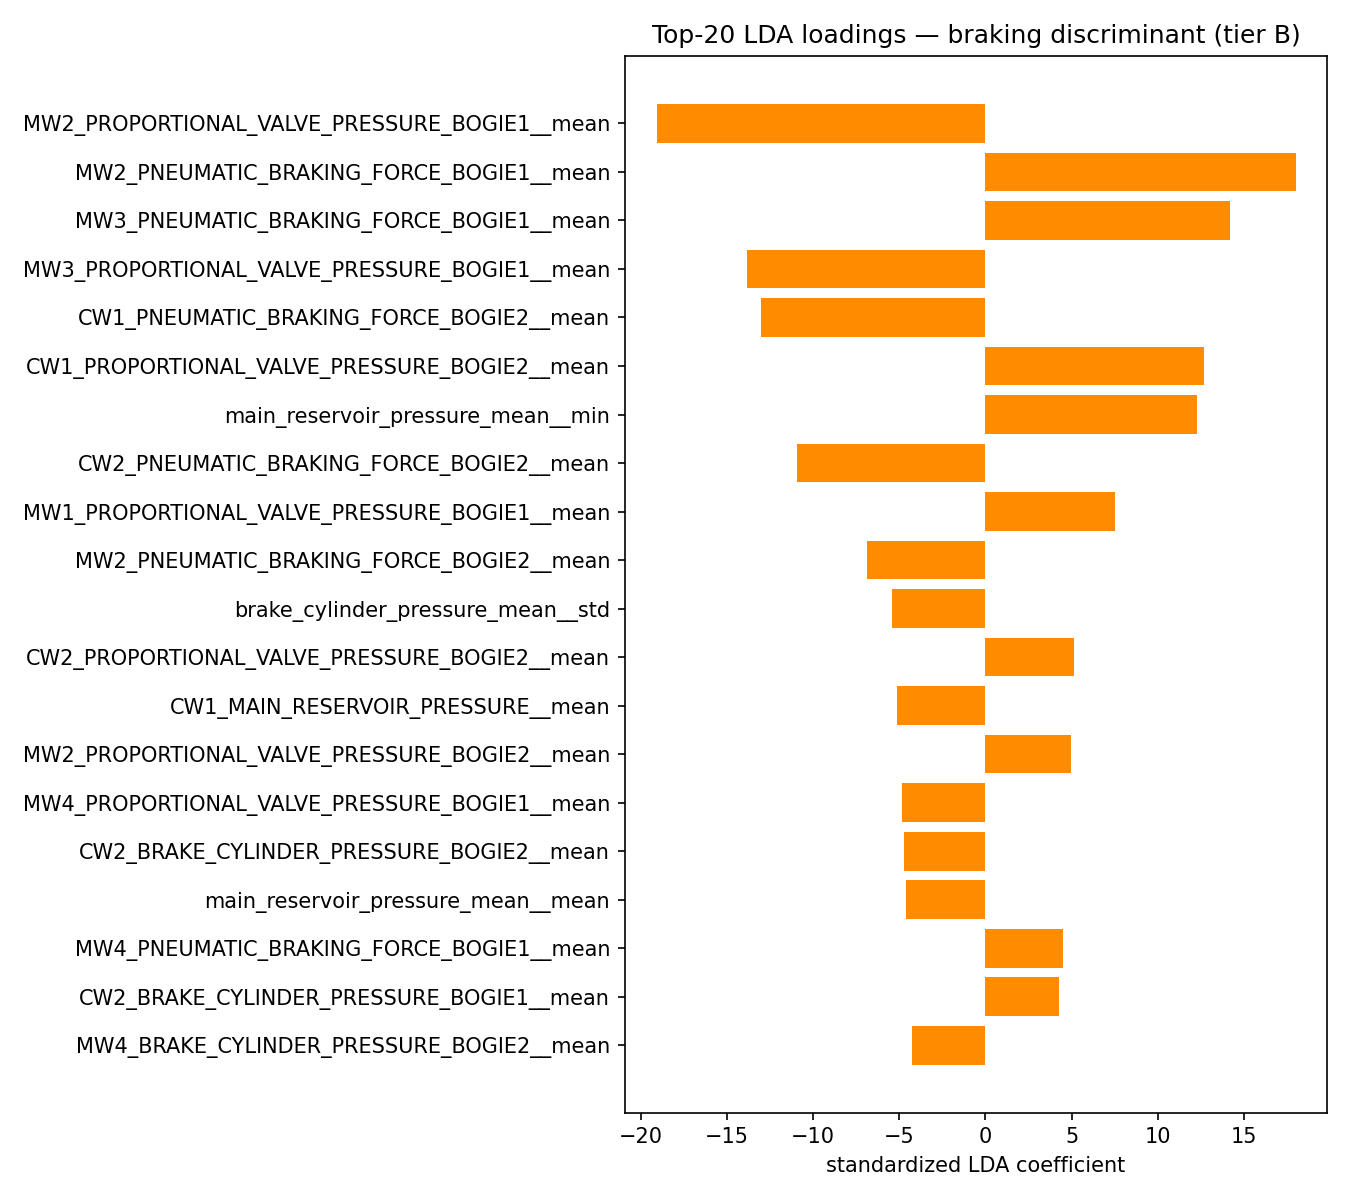

In [11]:
display(pd.read_csv(TABLES / "state_classification_metrics.csv").round(3))
display(Image(filename=str(P2 / "state_clf_comparison.png")))
display(Image(filename=str(P2 / "state_clf_confusion.png")))
display(Image(filename=str(P2 / "state_clf_lda_coeffs.png")))

**What it means:**
- The air sensors recover braking well. **Random Forest** is the strongest classifier (AUC = 0.954, F1 = 0.680 in the full tier), followed by LDA (0.924) and Decision Tree (0.910). All models comfortably beat chance (AUC = 0.5).
- The *auxiliary* sensors alone (no brake-command signal) already give RF AUC = 0.921 - braking leaves a real fingerprint across the air system even without the direct command input.
- **LDA with PCA pre-processing** (pca_lda, 15 components) is notably weaker (AUC ≈ 0.84) than direct LDA (0.92). Reducing to 15 PCA components loses discriminative structure: PCA axes maximise variance, not class separation, so some braking-vs-not signal is discarded. Regular LDA is preferable here.
- The Decision Tree is one of the simplest models yet scores near the top (AUC = 0.910), making it the most interpretable high-performing option.

## 3. Are there braking-intensity classes? -> No, it's a continuum

**What was done:** testing was performed to determine whether deceleration falls into distinct classes
(gentle/hard/emergency) using BIC + silhouette + stability - letting the data decide.

,k,gmm_bic,gmm_aic,kmeans_silhouette,davies_bouldin,bootstrap_ari,min_cluster_frac
0,1,940635.709,940547.967,NaN,NaN,NaN,NaN
1,2,884034.272,883849.040,0.406,0.925,0.992,0.408
2,3,811851.997,811569.274,0.407,0.714,0.832,0.000
3,4,782709.437,782329.223,0.390,0.797,0.868,0.000
4,5,778574.524,778096.820,0.315,0.899,0.964,0.000
5,6,767810.272,767235.077,0.278,0.973,0.678,0.000


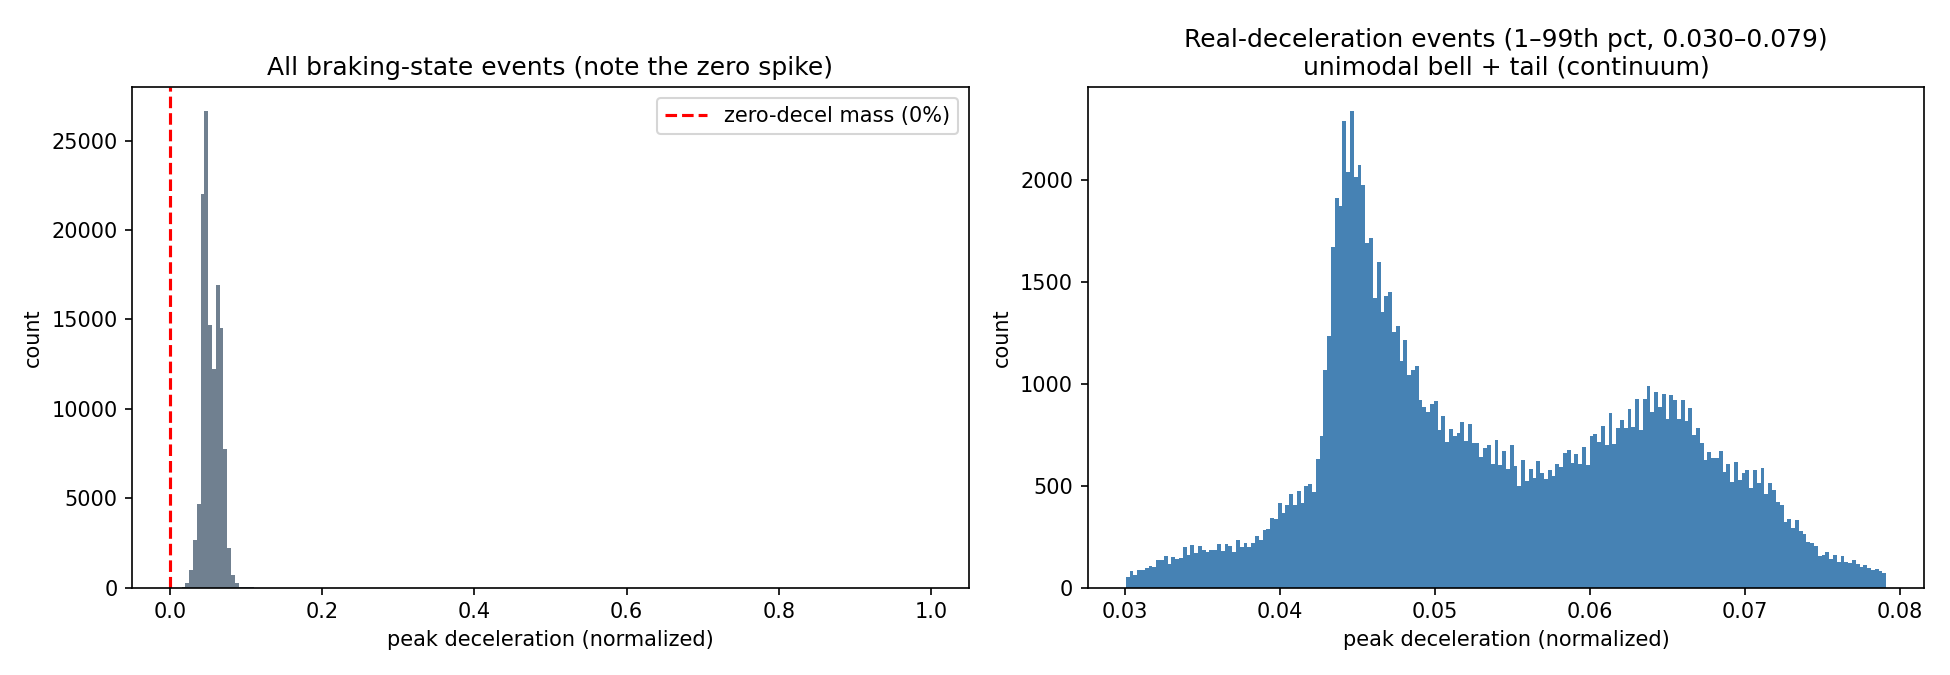

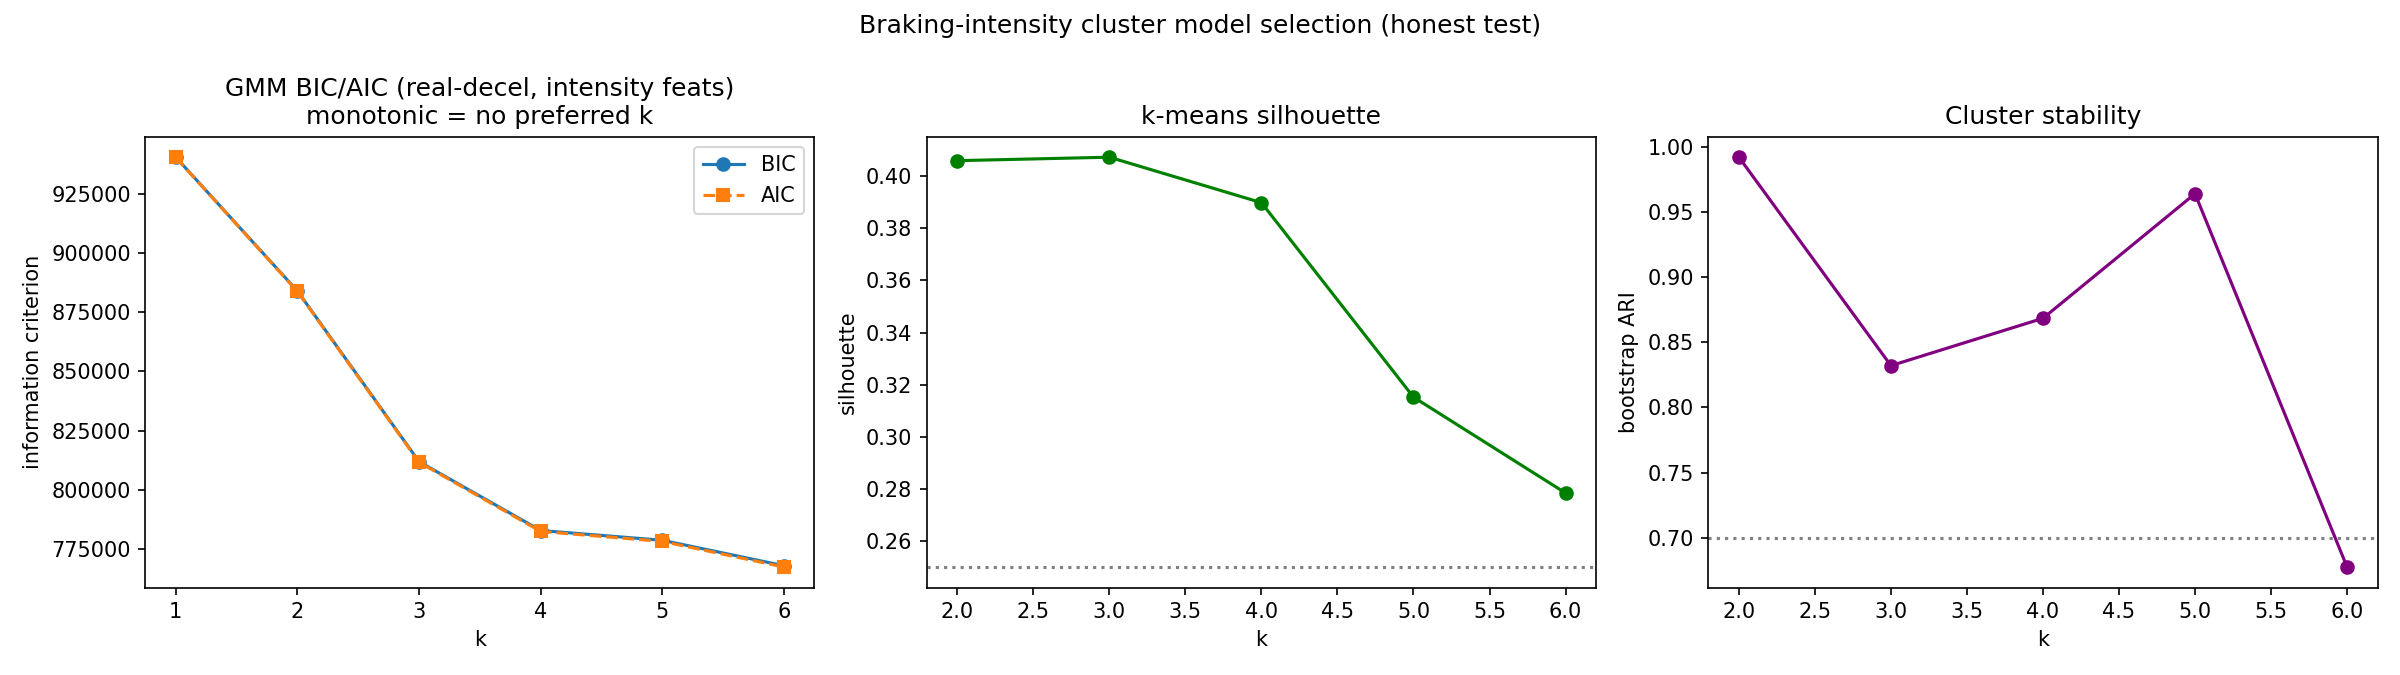

In [12]:
display(pd.read_csv(TABLES / "cluster_selection.csv").round(3))
display(Image(filename=str(P2 / "intensity_distribution.png")))
display(Image(filename=str(P2 / "cluster_model_selection.png")))

**What it means:** there is **no natural number of classes** - the score
keeps "improving" with more groups and the groups aren't stable. Deceleration is a smooth
**continuum** (one common level with a long tail of harder stops). Accordingly, no "light/hard/emergency" classes are introduced.

## 4. How much of braking *intensity* do the air sensors explain?

**What was done:** since intensity is continuous, the deceleration value was predicted from
the non-speed sensors (held-out R²; baseline = guessing the average).

,scope,target,tier,with_duration,model,n_features,r2,mae,baseline_r2,baseline_mae
0,real_decel,peak_deceleration,auxonly,False,lin,10,0.162,0.009,-0.0,0.010
1,real_decel,peak_deceleration,auxonly,False,ridge,10,0.129,0.009,-0.0,0.010
2,real_decel,peak_deceleration,auxonly,False,lasso,10,0.060,0.009,-0.0,0.010
3,real_decel,peak_deceleration,auxonly,False,tree,10,0.244,0.008,-0.0,0.010
4,real_decel,peak_deceleration,auxonly,True,lin,11,0.232,0.009,-0.0,0.010
5,real_decel,peak_deceleration,auxonly,True,ridge,11,0.198,0.009,-0.0,0.010
6,real_decel,peak_deceleration,auxonly,True,lasso,11,0.134,0.009,-0.0,0.010
7,real_decel,peak_deceleration,auxonly,True,tree,11,0.307,0.008,-0.0,0.010
8,real_decel,peak_deceleration,full,False,lin,22,0.243,0.008,-0.0,0.010
9,real_decel,peak_deceleration,full,False,ridge,22,0.211,0.008,-0.0,0.010


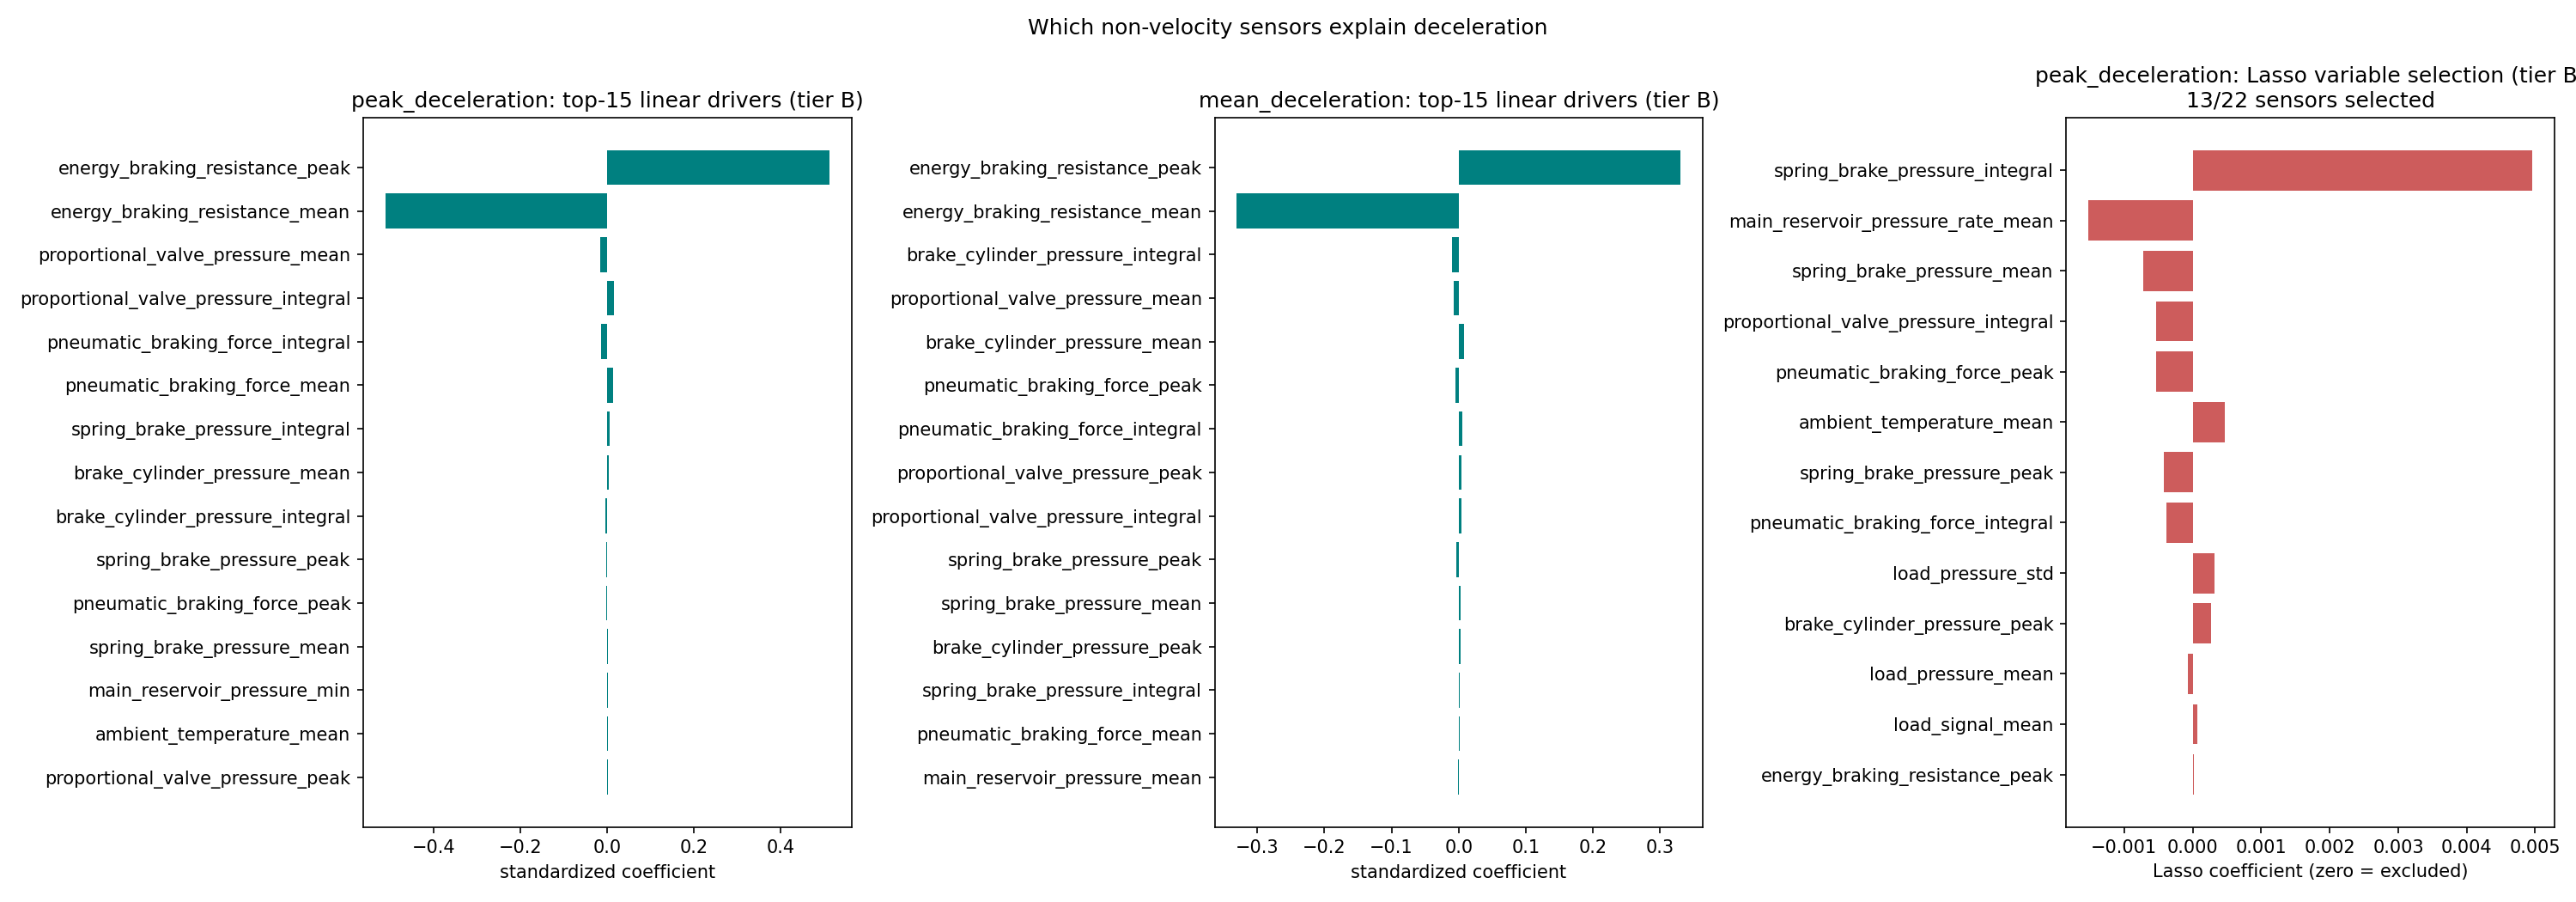

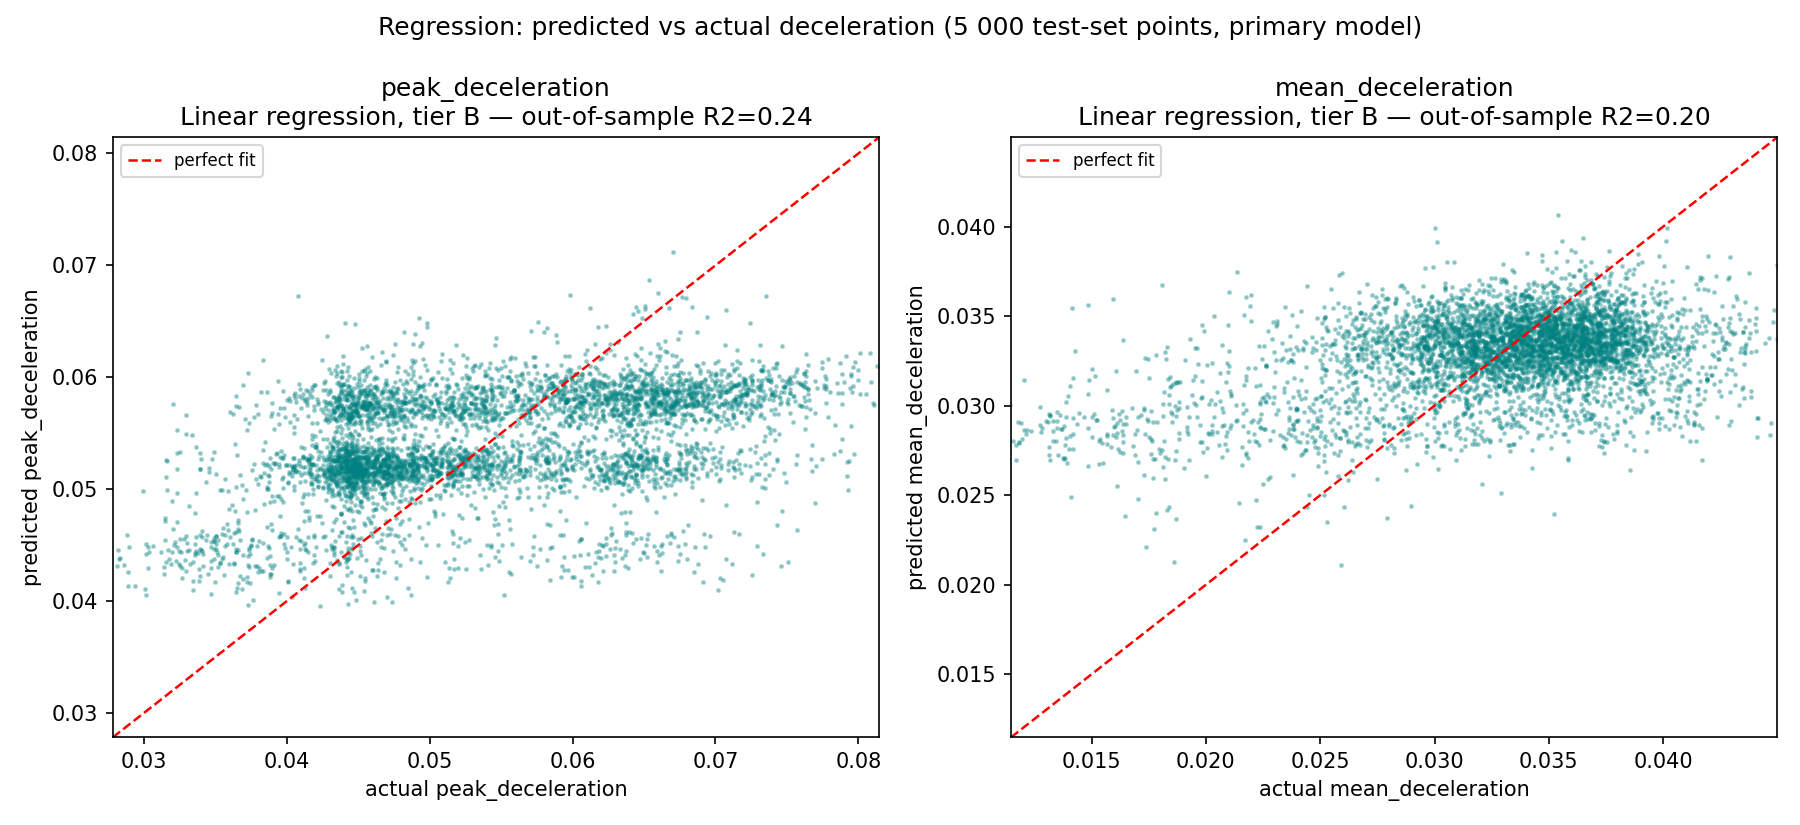

In [13]:
r = pd.read_csv(TABLES / "decel_regression_metrics.csv")
display(r[r.scope == "real_decel"].round(3).reset_index(drop=True))
display(Image(filename=str(P2 / "decel_regression_coeffs.png")))
display(Image(filename=str(P2 / "decel_regression_scatter.png")))

**What it means:**
- The gradient-boosting tree explains **~43% of peak** and **~47% of mean** deceleration out-of-sample (R²). Linear regression explains ~24%/~20% - the remaining gap indicates non-linear sensor–intensity relationships that a tree captures but a line cannot.
- The **scatter plot** confirms a real positive association: the predicted-vs-actual cloud has a clear positive slope, concentrated around the most common (mild) braking intensity, with harder stops forming a thinner tail that is more difficult to predict. The cloud width (scatter around the diagonal) reflects the genuine irreducible noise - variation in braking intensity not captured by these sensors.
- **Lasso variable selection** (L1-regularised, alpha = 0.0001) selects ~13 of the 22 air-system sensors and zeros the rest. The selected sensors include actuation (brake-cylinder pressure integral) and several auxiliary health sensors, confirming that the intensity signal is distributed across multiple subsystems. Note: the Lasso alpha was not cross-validated; a tuned alpha would improve predictive R² at the cost of selecting more features.

This is the headline result - fully cross-modal (pneumatics predicting kinematics), no class assumptions required.

## 5. Does braking change before a brake failure? (only 8 documented failures)

**Steps taken:**

**Step 1 - Distributional comparison.** For each of 10 key sensor features, all real-deceleration events were split into two groups:
- *Pre-failure window (7 d):* events in the 7 days **before** any of the 8 brake failures, pooled across failures (~35 k events total)
- *Baseline (> 30 d):* events further than 30 days from any failure - the "normal" reference

A Mann–Whitney U test was run per feature (are the two distributions different?) and **Cliff's delta** was computed - a measure of how large the difference actually is (0 = identical distributions, ±1 = fully separated). With ~35 k pre-failure events, nearly everything is "statistically significant" on a p-value basis, so **the effect size is read, not the p-value.** A |delta| < 0.15 is considered negligible regardless of p. A Bonferroni correction was also applied for the 10 simultaneous tests.

**Step 2 - CUSUM change-point detection.** The weekly mean of `main_reservoir_pressure_drop` (an auxiliary wear proxy) was computed and a **CUSUM alarm** was run on it. CUSUM accumulates small deviations from the running mean; when the cumulative sum exceeds a threshold (≈ 4 std units, tuned for ~1 false alarm per 6 months), it fires a change-point. It was then checked whether any change-point falls within 7 days *before* a failure.

**How to read the table:** rows are features, sorted by |Cliff's delta|. The `cliffs_delta` column is the key: values near 0 mean the pre-failure distribution is essentially the same as baseline. `sig_bonferroni = True` means the difference survives the multiple-test correction, but note: significance ≠ importance when the sample is large.

**How to read the CUSUM plot:** the blue line is the weekly reservoir-pressure-drop average over the full year. **Red** vertical lines are the 8 documented brake failures. **Green dashed** lines are CUSUM change-points. A "hit" would be a green line within 7 days to the left of a red line.

,feature,cliffs_delta,cliffs_ci_lo,cliffs_ci_hi,sig_bonferroni
9,energy_braking_resistance_mean,-0.201,-0.241,-0.163,True
8,load_pressure_mean,-0.103,-0.138,-0.067,True
4,jerk_rms,0.054,0.018,0.094,True
0,brake_cylinder_pressure_integral,-0.040,-0.077,-0.007,True
2,pneumatic_braking_force_mean,-0.032,-0.067,0.007,True
1,brake_cylinder_pressure_peak,-0.030,-0.070,0.004,True
3,spring_brake_pressure_mean,0.029,-0.002,0.064,True
7,main_reservoir_pressure_rate_mean,0.016,-0.018,0.049,True
6,main_reservoir_pressure_drop,-0.012,-0.050,0.023,False
5,peak_deceleration,-0.005,-0.040,0.026,False


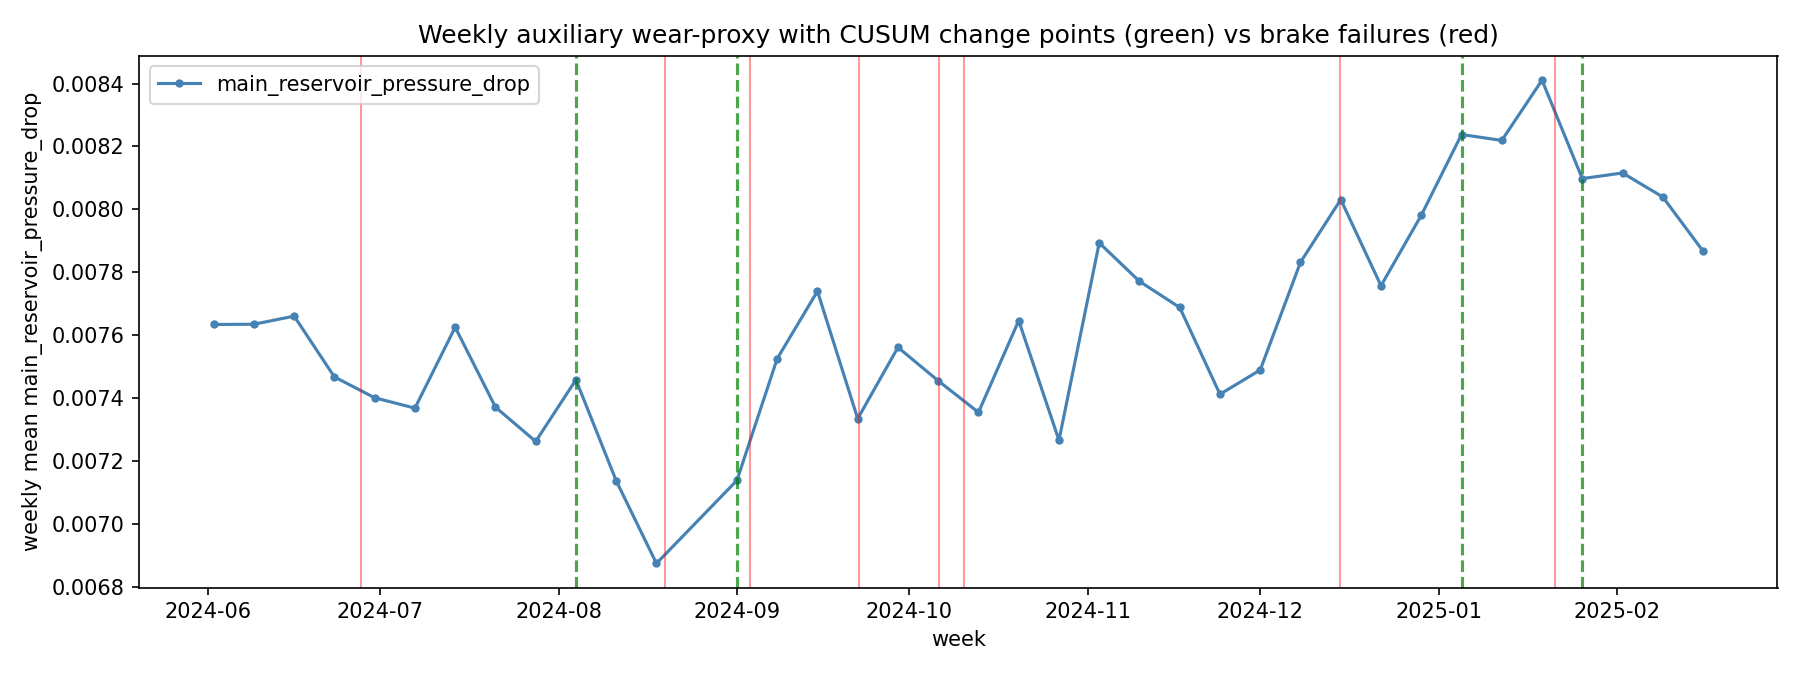

In [14]:
t = pd.read_csv(TABLES / "prefailure_tests.csv")
t["abs_delta"] = t["cliffs_delta"].abs()
display(t.sort_values("abs_delta", ascending=False)[
    ["feature", "cliffs_delta", "cliffs_ci_lo", "cliffs_ci_hi", "sig_bonferroni"]].round(3))
display(Image(filename=str(P2 / "prefailure_cusum.png")))

**What it means:**
- The **Cliff's delta column** shows near-zero effect sizes for almost all features. Only two auxiliary health sensors (energy-braking-resistance, load-pressure) show mild drifts (|delta| ≈ 0.1–0.15) before failures - these are the only features worth noting, and even they are small.
- The **CUSUM plot** shows change-points (green lines) scattered across the year with no consistent alignment to the failures (red lines). The reservoir pressure proxy does not reliably precede failures during the braking phase.
- **Why p-values are not the story:** with ~35 000 pooled pre-failure events, Mann–Whitney tests have enormous statistical power - even a trivially small distributional shift becomes "significant." Cliff's delta should be read; the p-value column can be ignored unless |delta| > 0.15.

**How confident:** Low - only 8 documented failures. This is a near-null result, not a failure detector.

**What this suggests:** brake-system failures likely manifest primarily during *charging and idle* phases (compressor cycling, reservoir recharge) rather than during deceleration. This analysis looked under the wrong lamppost. A follow-up analysis should apply the same test to *standing/cruising* windows using auxiliary sensors (compressor duty cycle, reservoir recharge time, spring-brake pressure at rest).

## Takeaways

1. Braking is **recoverable from the air sensors with no cheating** (AUC ≈ 0.9); the
   independent health sensors carry most of that signal.
2. Braking **intensity is a continuum**, not distinct classes.
3. Non-speed sensors explain **~43–47%** of how hard the train brakes (out-of-sample).
4. The **pre-failure braking signal is weak** (8 failures) - pointing toward an
   idle/charging follow-up.

Plain-language definitions of every method used in this notebook are in the
**[Glossary section of README.md](../README.md#glossary)**.